In [1]:
import pandas as pd
import tensorflow
import numpy as np
from keras.models import Sequential
from keras import optimizers
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras.applications import MobileNetV2
import matplotlib.pyplot as plt

In [2]:
base_model=MobileNetV2(include_top=False, weights="imagenet", input_shape=(224,224,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 65s 7us/step


In [2]:
model = Sequential()
#model.add(base_model)
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.40))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(7, activation='sigmoid'))

In [4]:
data=pd.read_csv("D:\Hoc tap\AI project\Skin_Cancer_Detection\data\HAM10000_metadata.csv")
data['image_full_name']=data['image_id']+'.jpg'
X=data[['image_full_name','dx','lesion_id']]

In [5]:
X.sample(5)

,image_full_name,dx,lesion_id
2865,ISIC_0030096.jpg,bcc,HAM_0003669
2274,ISIC_0030925.jpg,mel,HAM_0002613
1309,ISIC_0032044.jpg,mel,HAM_0004643
446,ISIC_0030812.jpg,bkl,HAM_0005558
6781,ISIC_0029985.jpg,nv,HAM_0004763


<Axes: xlabel='dx'>

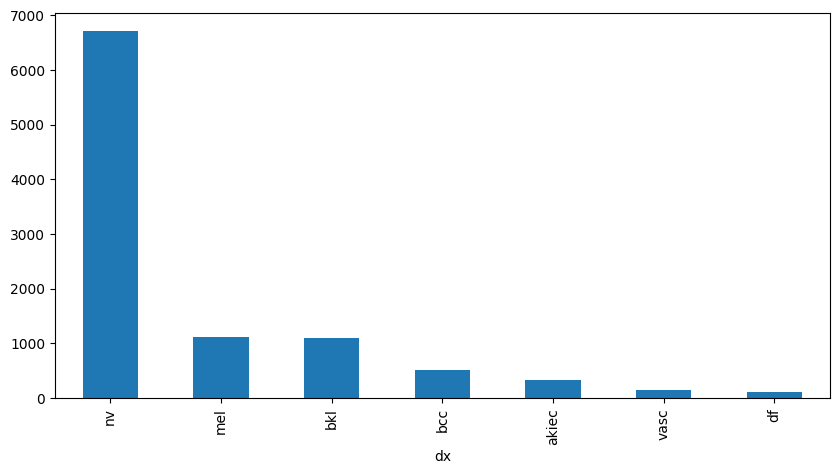

In [6]:
fig, ax1 = plt.subplots(1, 1, figsize= (10, 5))
X['dx'].value_counts().plot(kind='bar', ax=ax1)

In [7]:
from sklearn.model_selection import train_test_split
Y=X.pop('dx').to_frame()
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.1, random_state=42)
X_train,X_val,y_train,y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [8]:
train=pd.concat([X_train,y_train],axis=1)
val=pd.concat([X_val,y_val],axis=1)
test=pd.concat([X_test,y_test],axis=1)

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
encoder.fit(val['dx'])
name_as_indexes_train=encoder.transform(val['dx']) 
val['label']=name_as_indexes_train

In [10]:
encoder=LabelEncoder()
encoder.fit(test['dx'])
name_as_indexes_test=encoder.transform(test['dx']) 
test['label']=name_as_indexes_test

In [11]:
from keras_preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(rescale = 1./255,
                                     rotation_range=10,  
                                     zoom_range = 0.1, 
                                     width_shift_range=0.0,  height_shift_range=0.00) 

In [15]:
train_data= train_generator.flow_from_dataframe(dataframe=train,x_col="image_full_name",y_col="dx",
                                                batch_size=32,directory="D:\Hoc tap\AI project\Skin_Cancer_Detection\data\HAM10000_images",
                                                shuffle=True,class_mode="categorical",target_size=(224,224))

Found 7298 validated image filenames belonging to 7 classes.


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:279: UserWarning: Found 813 invalid image filename(s) in x_col="image_full_name". These filename(s) will be ignored.
  warnings.warn(


In [16]:
test_generator=ImageDataGenerator(rescale = 1./255,rotation_range=10,  
                                     zoom_range = 0.1, 
                                     width_shift_range=0.0,  height_shift_range=0.02)

In [17]:
test_data= test_generator.flow_from_dataframe(dataframe=test,x_col="image_full_name",y_col="dx",
                                              directory="D:\Hoc tap\AI project\Skin_Cancer_Detection\data\Test_images",
                                              shuffle=False,batch_size=1,class_mode=None,target_size=(224,224))

Found 88 validated image filenames.


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:279: UserWarning: Found 914 invalid image filename(s) in x_col="image_full_name". These filename(s) will be ignored.
  warnings.warn(


In [18]:
val_data=test_generator.flow_from_dataframe(dataframe=val,x_col="image_full_name",y_col="dx",
                                            directory="D:\Hoc tap\AI project\Skin_Cancer_Detection\data\HAM10000_images",
                                            batch_size=64,shuffle=False,class_mode="categorical",target_size=(224,224))

Found 803 validated image filenames belonging to 7 classes.


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras_preprocessing\image\dataframe_iterator.py:279: UserWarning: Found 99 invalid image filename(s) in x_col="image_full_name". These filename(s) will be ignored.
  warnings.warn(


In [19]:
from keras.callbacks import ReduceLROnPlateau
learning_control = ReduceLROnPlateau(monitor='val_acc', patience=3, verbose=1, factor=.5, min_lr=0.0001)

In [20]:
from keras.optimizers import Adam,SGD
sgd = optimizers.SGD(learning_rate = 0.01, clipvalue = 0.5)
model.compile(optimizer=sgd,loss="categorical_crossentropy",metrics=["accuracy"])

In [21]:
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_data=val_data,
    validation_steps=val_data.samples // val_data.batch_size,
    epochs=30,
    callbacks=[learning_control],
    verbose=1
)

Epoch 1/30


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


228/228 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.6281 - loss: 1.4906 - val_accuracy: 0.6576 - val_loss: 1.0345 - learning_rate: 0.0100
Epoch 2/30


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\callbacks\callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


  1/228 ━━━━━━━━━━━━━━━━━━━━ 2:25 643ms/step - accuracy: 0.6250 - loss: 1.1385

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6250 - loss: 1.1385 - val_accuracy: 0.6571 - val_loss: 1.0475 - learning_rate: 0.0100
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 188s 816ms/step - accuracy: 0.6715 - loss: 1.0587 - val_accuracy: 0.6576 - val_loss: 0.9630 - learning_rate: 0.0100
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7188 - loss: 0.8786 - val_accuracy: 0.6571 - val_loss: 1.0339 - learning_rate: 0.0100
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 184s 798ms/step - accuracy: 0.6732 - loss: 1.0025 - val_accuracy: 0.6576 - val_loss: 0.9512 - learning_rate: 0.0100
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5938 - loss: 1.1292 - val_accuracy: 0.6571 - val_loss: 1.0316 - learning_rate: 0.0100
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 185s 804ms/step - accuracy: 0.6714 - loss: 0.9783 - val_accuracy: 0.6576 - val_loss: 0.9269 - learning_rate: 0.0100
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6875 - loss: 0.8763 -

In [22]:
model.save('model123456.h5')

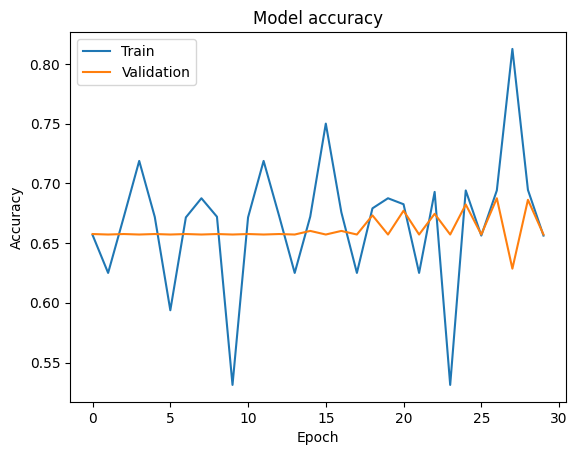

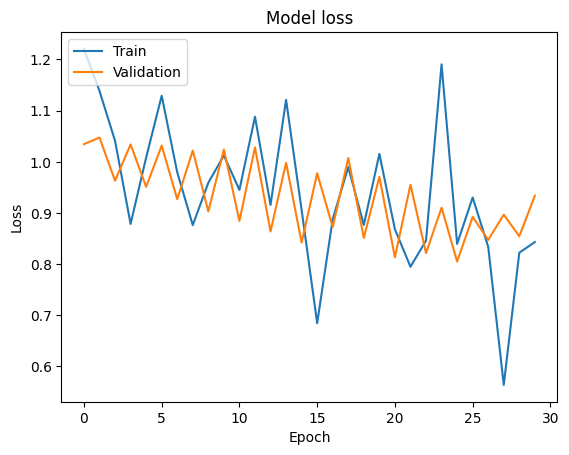

In [23]:
import matplotlib.pyplot as plt

# Vẽ độ chính xác của mô hình
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Vẽ mất mát (loss) của mô hình
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

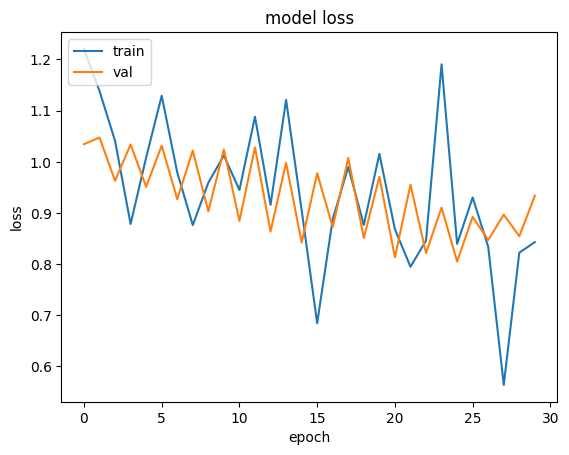

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

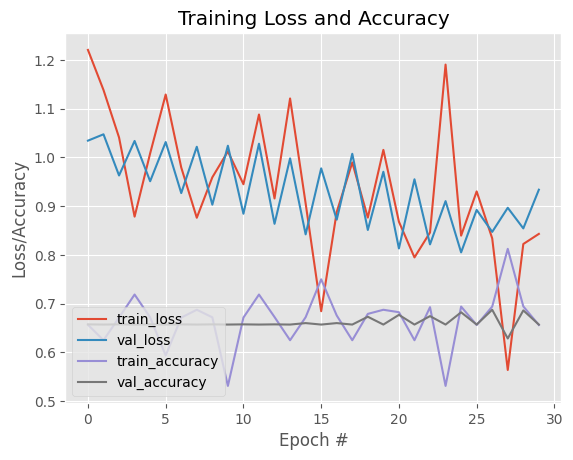

In [25]:
N = 30
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["accuracy"], label="train_accuracy")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")


In [26]:
# test_data.reset()
# predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
# y_pred= np.argmax(predictions, axis=1)
test_data.reset()
predictions = model.predict(test_data, steps=test_data.samples // test_data.batch_size, verbose=1)
y_pred = np.argmax(predictions, axis=1)


 5/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


In [48]:
#c=np.where(y_pred == name_as_indexes_test)
#c = np.where(y_pred == name_as_indexes_test)[0]
c = np.where(y_pred == name_as_indexes_test[:, None])[0]


In [43]:
np.count_nonzero(c)

54102

In [46]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 5399.4011976047905
